In [1]:
%load_ext autoreload

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib import container
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
import tabulate 

import IPython

In [3]:
%autoreload 2

from util import *

In [4]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# Load Data

In [5]:
# CPI: https://www.minneapolisfed.org/about-us/monetary-policy/inflation-calculator/consumer-price-index-1913-
cpi_map = {
    2013: 233,
    2014: 236.7,
    2015: 237,
    2016: 240,
    2017: 245.1,
    2018: 251.1,
    2019: 255.7,
    2020: 258.8,
    2021: 271,
    2022: 292.7,
    2023: 304.7,
    2024: 313.7,
    2025: 322.3
}

In [6]:
spine_addons = [
    "22552", "63082", "22585", "22585", "22632", "22614", "63048", "23078", "63086", "63088", "63103", "22585",
    "63048", "63066", "63086", "63091", "22585", "63044", "63048", "22632", "22614", "22634", "63035", "63043",
    "63053", "63057", "63076", "63076", "22534"
]

pain_addons = ["64491", "64492", "64495", "64634", "64636", "64484", "64629", "22512", "22515"]

In [51]:
cpt_spine = {
    "instrumentation": [
        "22840", "22842", "22843", "22844", "22845", "22846", "22847", "22853", 
        "22854", "22859", "22849"
    ],
    "bone_grafting": [
        "20930", "20931", "20936", "20937", "20938", "20939"
    ],
    "decompression": [
        "63001", "63015", "63045", "63020", "63040", "63043", "63048", "63035", 
        "63050", "63051", "63075", "63076", "63081", "63082", "63003", "63016",
        "63046", "63085", "63086", "63087", "63005", "63017", "63047", "63030",
        "63042", "63044", "63052", "63053", "62380", "63090", "63091", "63012",
        "63055", "63057", "63064", "63066", "63077", "63088", "63101", "63103"
    ],
    "fusion": [
        "22800", "22802", "22804", "22810", "22812", "22585", "22614", "22534", 
        "22551", "22552", "22554", "22590", "22595", "22556", "22532", "22558",
        "22533", "22612", "22630", "22632", "22633", "22634", "22548", "22600",
        "22610", "23078", "23085"
    ],
}   

cpt_pain = {
    "facet_block": ["64490", "64493", "64491", "64492", "64495"],
    "esi": ["64483", "64484"],
    "esi_new": ["62320", "62321", "62322", "62323"],
    "deleted_esi": ["62310", "62311", "62312", "62313", "62314", "62315", "62316", "62317", "62318", "62319"],
    "rfa": ["64633", "64634", "64635", "64636", "64628", "64629"],
    "vertebral_augmentation": ["22510", "22511", "22512", "22513", "22514", "22515"],
}

In [52]:
for name in cpt_spine:
    print(name)
    print(", ".join([code for code in cpt_spine[name] if code not in spine_addons]))

instrumentation
22840, 22842, 22843, 22844, 22845, 22846, 22847, 22853, 22854, 22859, 22849
bone_grafting
20930, 20931, 20936, 20937, 20938, 20939
decompression
63001, 63015, 63045, 63020, 63040, 63050, 63051, 63075, 63081, 63003, 63016, 63046, 63085, 63087, 63005, 63017, 63047, 63030, 63042, 63052, 62380, 63090, 63012, 63055, 63064, 63077, 63101
fusion
22800, 22802, 22804, 22810, 22812, 22551, 22554, 22590, 22595, 22556, 22532, 22558, 22533, 22612, 22630, 22633, 22548, 22600, 22610, 23085


In [53]:
for name in cpt_pain:
    print(name)
    print(", ".join([code for code in cpt_pain[name] if code not in pain_addons]))

facet_block
64490, 64493
esi
64483
esi_new
62320, 62321, 62322, 62323
deleted_esi
62310, 62311, 62312, 62313, 62314, 62315, 62316, 62317, 62318, 62319
rfa
64633, 64635, 64628
vertebral_augmentation
22510, 22511, 22513, 22514


In [54]:
cpt_map = {}

for category, codes in cpt_spine.items():
    for code in codes:
        if code not in spine_addons:
            cpt_map[int(code)] = category

for category, codes in cpt_pain.items():
    for code in codes:
        if code not in pain_addons:
            cpt_map[int(code)] = category

In [55]:
current_dir = os.getcwd()

In [56]:
spine_data = pd.read_csv(os.path.join(current_dir, "processed-data", "spine_cpt_processed.csv"))
pain_data = pd.read_csv(os.path.join(current_dir, "processed-data", "pain_cpt_processed.csv"))

# Set Up Dataframes

In [57]:
for df in [spine_data, pain_data]:
    df['CPI'] = df['year'].map(cpi_map).fillna(0)
    
    # Adjusted amounts
    df['Avg_Mdcr_Stdzd_Amt_adj'] = df['Avg_Mdcr_Stdzd_Amt'] / df['CPI'] * cpi_map[2023]
    df['Avg_Mdcr_Pymt_Amt_adj'] = df['Avg_Mdcr_Pymt_Amt'] / df['CPI'] * cpi_map[2023]

    # Raw amounts summed over services per provider
    df['Tot_Srvcs_Spend'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt'] 
    df['Tot_Pymt'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt'] 

    # Raw amounts summed over services per provider, adjusted
    df['Tot_Srvcs_Spend_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt_adj'] 
    df['Tot_Pymt_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt_adj'] 

# Select only necessary comlumns
spine_data = spine_data[[
    "HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", 
    "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj",
    "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"
]]
pain_data = pain_data[[
    "HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", 
    "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj",
    "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"
]]

for data in [spine_data, pain_data]:
    data['procedure'] = data['HCPCS_Cd'].map(cpt_map)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_28210/571844471.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['procedure'] = data['HCPCS_Cd'].map(cpt_map)


In [58]:
groupby_key = 'procedure'
specialty_name = ["Spine", "Interventional Pain"]

# Group by procedure and year, and summarize
util_2023_2013_adj_spine = (
    spine_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
    )
)

util_2023_2013_adj_pain = (
    pain_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique()))
)

# Get CIs for Avg_Mdcr_Stdzd_Amt
ci_spine = bootstrap_agg_price_ci(spine_data, groupby_key)
util_2023_2013_adj_spine = util_2023_2013_adj_spine.merge(ci_spine, on=[groupby_key, 'year'], how='left')

ci_pain = bootstrap_agg_price_ci(pain_data, groupby_key)
util_2023_2013_adj_pain = util_2023_2013_adj_pain.merge(ci_pain, on=[groupby_key, 'year'], how='left')

In [59]:
for df in [util_2023_2013_adj_spine, util_2023_2013_adj_pain]:
    df['Agg_Price_per_service_adj'] = df['Sum_Spend_adj'] / df['Sum_Utilization']

In [60]:
# util_2023_2013_adj_spine = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] >= 2016].reset_index(drop=True)
# util_2023_2013_adj_pain = util_2023_2013_adj_pain[util_2023_2013_adj_pain['year'] >= 2016].reset_index(drop=True)

# Utilization

In [61]:
util_2023_2013_adj_spine['Sum_Utilization'].sum(), util_2023_2013_adj_pain['Sum_Utilization'].sum()

(2158148.0, 230163.0)

In [62]:
spine_util_2013 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2013]['Sum_Utilization'].sum()
spine_util_2023 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2023]['Sum_Utilization'].sum()

(spine_util_2023 - spine_util_2013) / spine_util_2013 * 100

18.21494074709911

In [63]:
pain_util_2013 = util_2023_2013_adj_pain[util_2023_2013_adj_pain['year'] == 2013]['Sum_Utilization'].sum()
pain_util_2023 = util_2023_2013_adj_pain[util_2023_2013_adj_pain['year'] == 2023]['Sum_Utilization'].sum()

(pain_util_2023 - pain_util_2013) / pain_util_2013 * 100

-36.62246844065026

In [64]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_pain]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Utilization',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [65]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: 1.698 | weighted AAGR: 4.267

    procedure           AAGR_%
--  ---------------  ---------
 0  bone_grafting    -2.59251
 1  decompression    -2.58556
 2  fusion           -0.907139
 3  instrumentation  12.8779

Interventional Pain | unweighted AAGR: -3.952 | weighted AAGR: -5.09

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi              -1.68662
 1  esi                      -6.03591
 2  esi_new                 -12.6762
 3  facet_block              -1.4472
 4  rfa                       5.10094
 5  vertebral_augmentation   -6.96834



In [66]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Interventional Pain'][0]['AAGR_%'])

Ttest_indResult(statistic=1.3206827509360437, pvalue=0.2231351078450213)

In [67]:
cagrs = {}
for i, df in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_pain]):
    cagrs[specialty_name[i]] = compute_cagr(
        df,
        col='Sum_Utilization',
        groupby_key='procedure',
        years=[2013, 2023]
    )

In [68]:
for specialty, cagr in cagrs.items():
    print(specialty)
    print(tabulate.tabulate(cagr, headers=cagr.columns))
    print()

Spine
    procedure          CAGR_pct    effective_start_year    effective_end_year
--  ---------------  ----------  ----------------------  --------------------
 0  bone_grafting      -3.48735                    2013                  2023
 1  decompression      -2.96266                    2013                  2023
 2  fusion             -1.20413                    2013                  2023
 3  instrumentation     8.80063                    2013                  2023

Interventional Pain
    procedure                 CAGR_pct    effective_start_year    effective_end_year
--  ----------------------  ----------  ----------------------  --------------------
 0  deleted_esi               -5.63515                    2013                  2016
 1  esi                       -6.55747                    2013                  2023
 2  esi_new                  -13.323                      2017                  2023
 3  facet_block               -1.71642                    2013                  

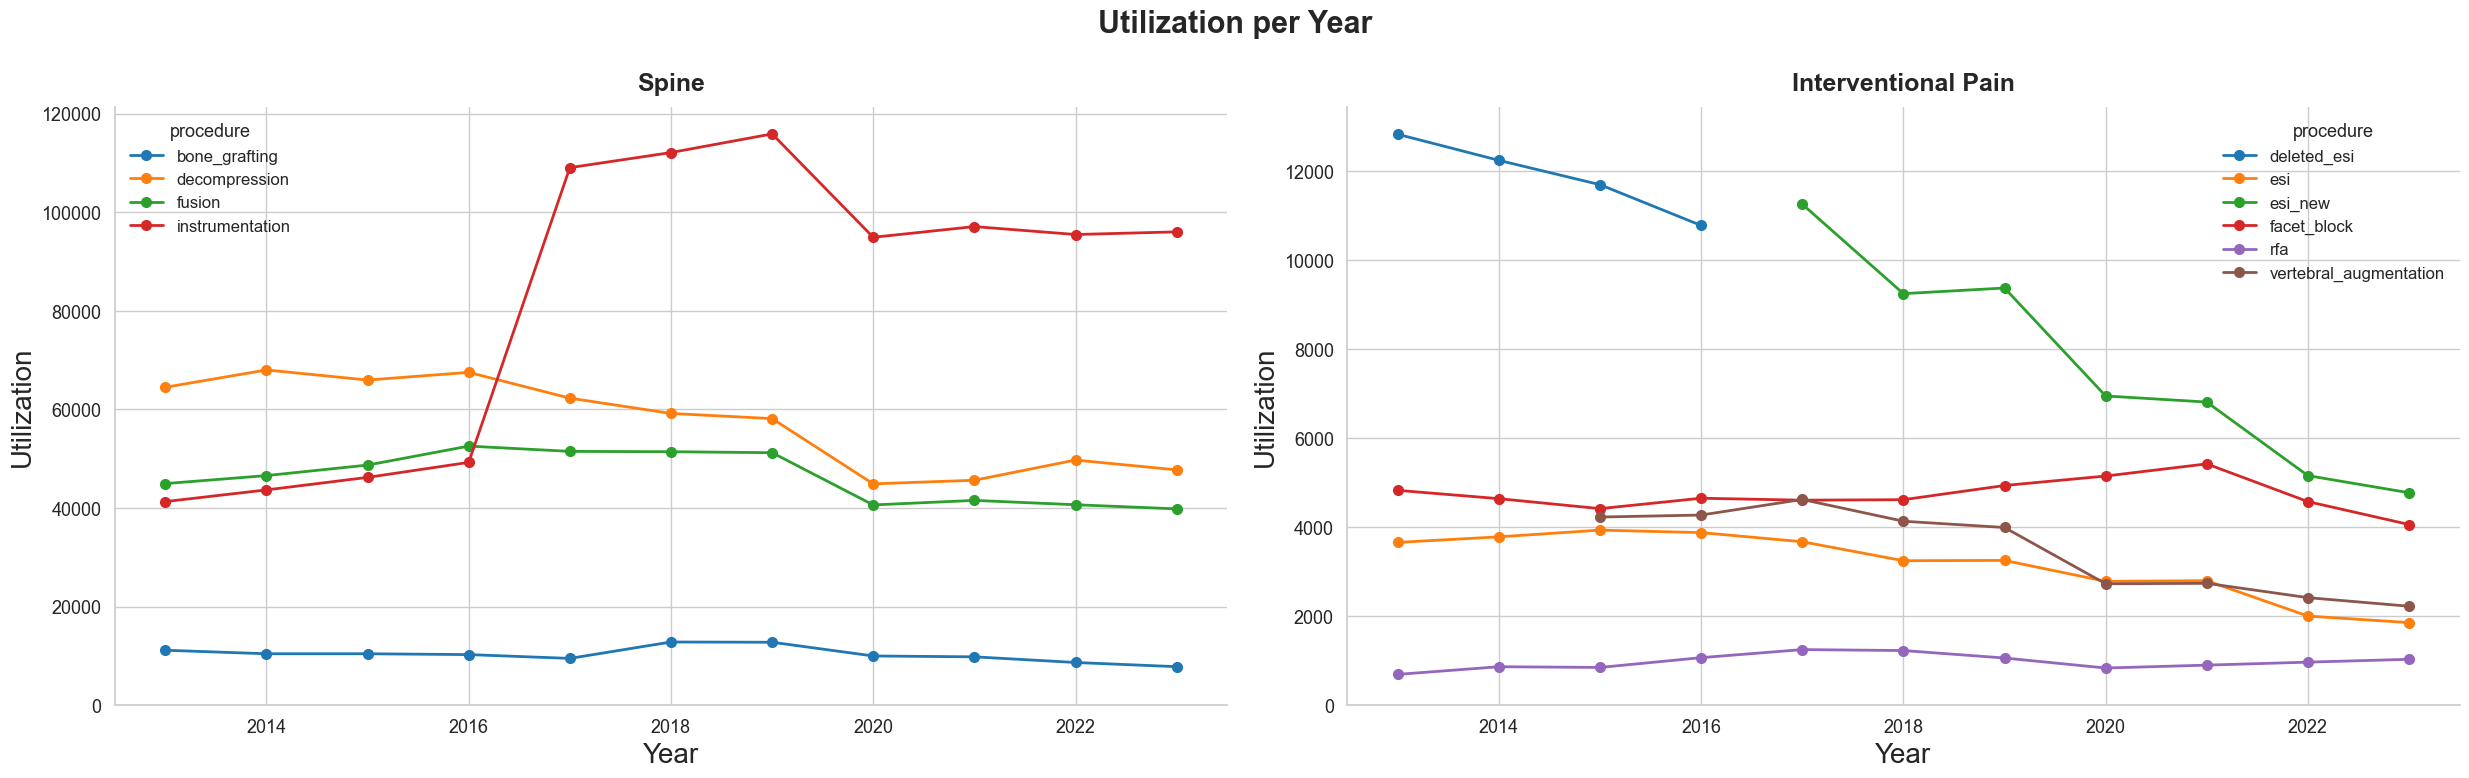

In [69]:
plot_by_specialty(
    [util_2023_2013_adj_spine, util_2023_2013_adj_pain],
    specialty_name,
    y_col='Sum_Utilization',
    y_label='Utilization',
    figsize=(25, 8),
    title="Utilization per Year"
)

# Average Standardized Payment

In [70]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_pain]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Avg_Price_per_service_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [71]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -4.098 | weighted AAGR: -3.725

    procedure          AAGR_%
--  ---------------  --------
 0  bone_grafting    -4.2677
 1  decompression    -3.98315
 2  fusion           -2.89291
 3  instrumentation  -5.24987

Interventional Pain | unweighted AAGR: 1.479 | weighted AAGR: 2.723

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi              3.59525
 1  esi                     -0.234944
 2  esi_new                 -1.46685
 3  facet_block              1.35145
 4  rfa                      1.89327
 5  vertebral_augmentation   3.73743



In [72]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Interventional Pain'][0]['AAGR_%'])

Ttest_indResult(statistic=-4.967797946616108, pvalue=0.001096122986919842)

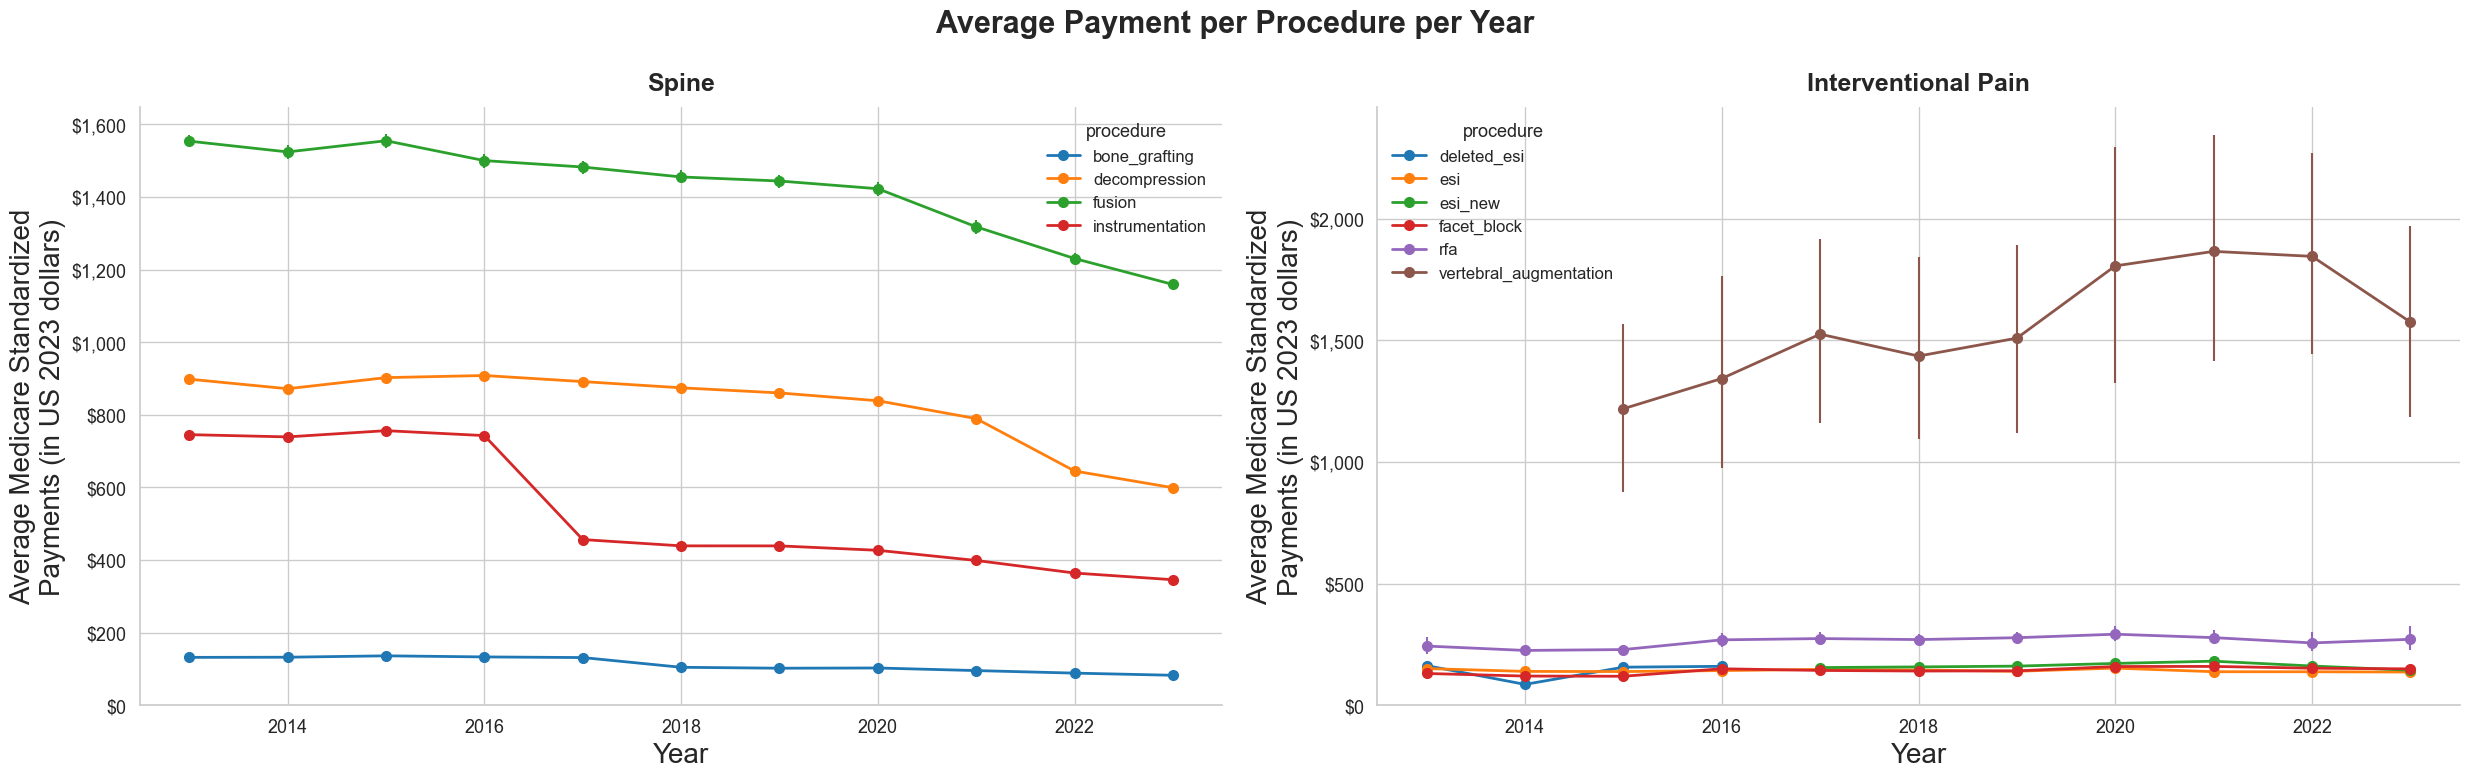

In [73]:
# Usage
plot_by_specialty_with_ci(
    [util_2023_2013_adj_spine, util_2023_2013_adj_pain],
    specialty_name,
    y_col='Agg_Price_per_service_adj',
    ci_lower_col='CI_lower_agg_price_adj',
    ci_upper_col='CI_upper_agg_price_adj',
    y_label="Average Medicare Standardized\nPayments (in US 2023 dollars)",
    title_prefix="Average Medicare Standardized Payment by Procedure Type",
    title="Average Payment per Procedure per Year"
)

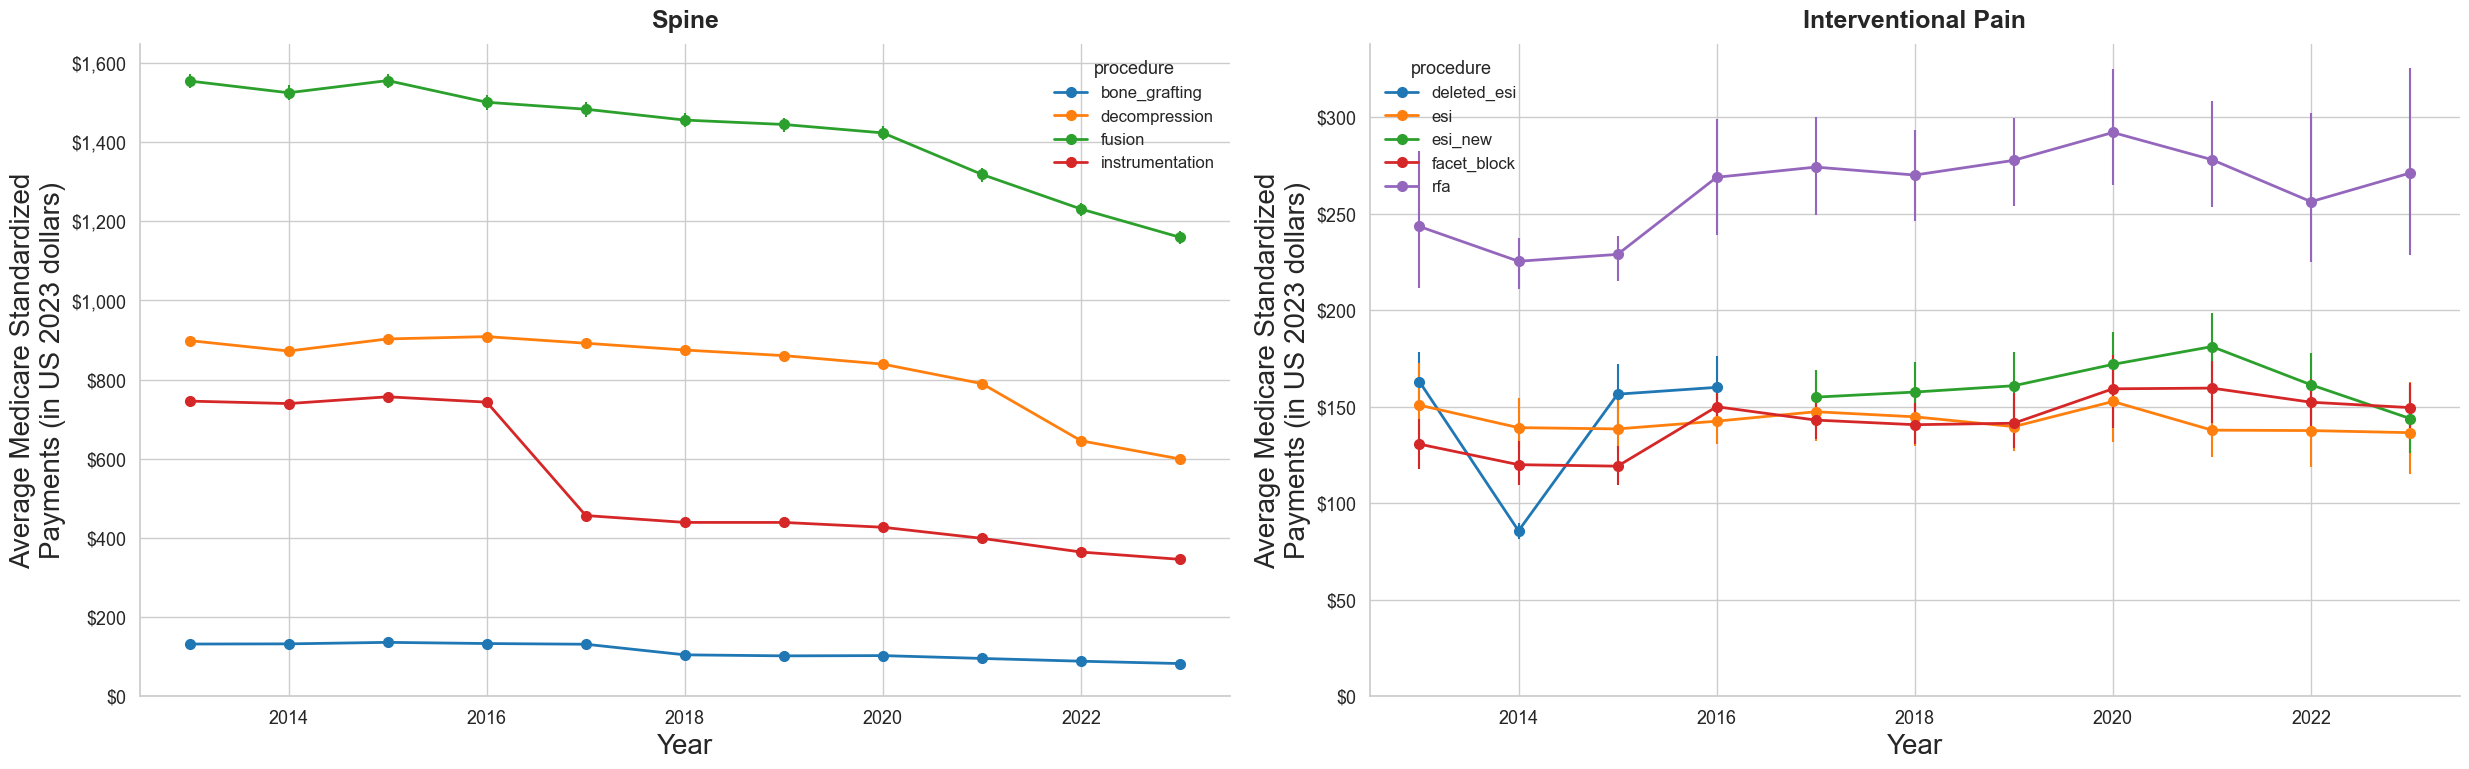

In [74]:
# Usage
plot_by_specialty_with_ci(
    [util_2023_2013_adj_spine[util_2023_2013_adj_spine['procedure'] != "vertebral_augmentation"], util_2023_2013_adj_pain[util_2023_2013_adj_pain['procedure'] != "vertebral_augmentation"]],
    specialty_name,
    y_col='Agg_Price_per_service_adj',
    ci_lower_col='CI_lower_agg_price_adj',
    ci_upper_col='CI_upper_agg_price_adj',
    y_label="Average Medicare Standardized\nPayments (in US 2023 dollars)",
    title_prefix="Average Medicare Standardized Payment by Procedure Type",
)

# Total Payment

In [75]:
util_2023_2013_adj_spine['Sum_Pymt_adj'].sum(), util_2023_2013_adj_pain['Sum_Pymt_adj'].sum()

(1662617872.321856, 76756068.2166813)

In [76]:
spine_total_payment_2013 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2013]['Sum_Pymt_adj'].sum()
spine_total_payment_2023 = util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'] == 2023]['Sum_Pymt_adj'].sum()

(spine_total_payment_2023 - spine_total_payment_2013) / spine_total_payment_2013 * 100

-29.50446785416495

In [77]:
pain_total_payment_2013 = util_2023_2013_adj_pain[util_2023_2013_adj_pain['year'] == 2013]['Sum_Pymt_adj'].sum()
pain_total_payment_2023 = util_2023_2013_adj_pain[util_2023_2013_adj_pain['year'] == 2023]['Sum_Pymt_adj'].sum()

(pain_total_payment_2023 - pain_total_payment_2013) / pain_total_payment_2013 * 100

50.61444108540331

In [78]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_pain]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [79]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -3.634 | weighted AAGR: -2.874

    procedure          AAGR_%
--  ---------------  --------
 0  bone_grafting    -7.09832
 1  decompression    -6.25081
 2  fusion           -3.22924
 3  instrumentation   2.04069

Interventional Pain | unweighted AAGR: -3.331 | weighted AAGR: -3.592

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi               1.62578
 1  esi                      -8.12079
 2  esi_new                 -12.8976
 3  facet_block              -2.21223
 4  rfa                       4.90786
 5  vertebral_augmentation   -3.28782



In [80]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Interventional Pain'][0]['AAGR_%'])

Ttest_indResult(statistic=-0.0826058710133129, pvalue=0.9361944066789867)

In [81]:
cagrs = {}
for i, df in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_pain]):
    cagrs[specialty_name[i]] = compute_cagr(
        df,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
        years=[2013, 2023]
    )

In [82]:
for specialty, cagr in cagrs.items():
    print(specialty)
    print(tabulate.tabulate(cagr, headers=cagr.columns))
    print()

Spine
    procedure          CAGR_pct    effective_start_year    effective_end_year
--  ---------------  ----------  ----------------------  --------------------
 0  bone_grafting      -7.52743                    2013                  2023
 1  decompression      -6.59853                    2013                  2023
 2  fusion             -3.55797                    2013                  2023
 3  instrumentation     1.14286                    2013                  2023

Interventional Pain
    procedure                 CAGR_pct    effective_start_year    effective_end_year
--  ----------------------  ----------  ----------------------  --------------------
 0  deleted_esi               -6.07763                    2013                  2016
 1  esi                       -8.51214                    2013                  2023
 2  esi_new                  -13.9603                     2017                  2023
 3  facet_block               -2.77635                    2013                  

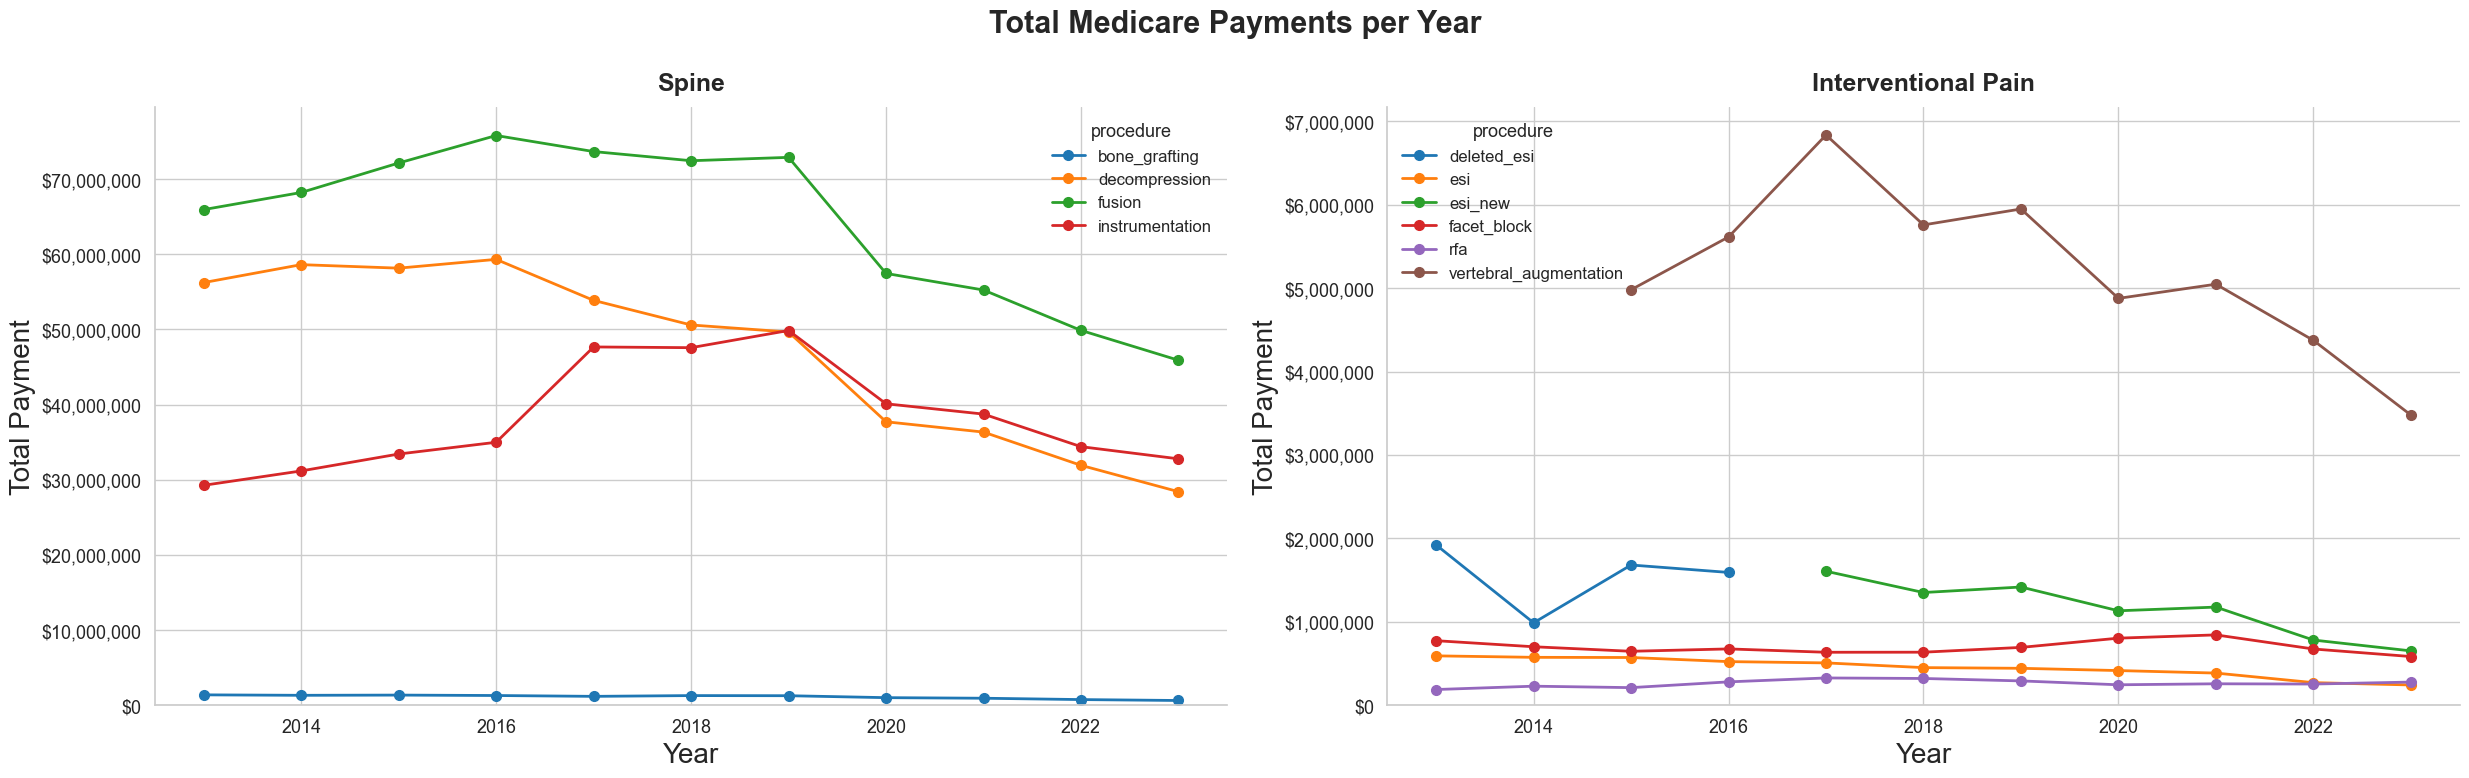

In [83]:
plot_by_specialty(
    [util_2023_2013_adj_spine, util_2023_2013_adj_pain],
    specialty_name,
    y_col='Sum_Pymt_adj',
    y_label='Total Payment',
    figsize=(25, 8),
    format_as_dollar=True,
    title="Total Medicare Payments per Year"
)

# Total Payment Growth Rate

In [84]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_pain]):
    aagr, unweighted, weighted = compute_aagr(
        specialty,
        col='Sum_Pymt_adj',
        groupby_key='procedure',
    )
    aagrs[specialty_name[i]] = (aagr, unweighted, weighted)

In [85]:
for specialty, (aagr, unweighted, weighted) in aagrs.items():
    print(f"{specialty} | unweighted AAGR: {round(unweighted, 3)} | weighted AAGR: {round(weighted, 3)}")
    print()
    print(tabulate.tabulate(aagr, headers=aagr.columns))
    print()

Spine | unweighted AAGR: -3.634 | weighted AAGR: -2.874

    procedure          AAGR_%
--  ---------------  --------
 0  bone_grafting    -7.09832
 1  decompression    -6.25081
 2  fusion           -3.22924
 3  instrumentation   2.04069

Interventional Pain | unweighted AAGR: -3.331 | weighted AAGR: -3.592

    procedure                  AAGR_%
--  ----------------------  ---------
 0  deleted_esi               1.62578
 1  esi                      -8.12079
 2  esi_new                 -12.8976
 3  facet_block              -2.21223
 4  rfa                       4.90786
 5  vertebral_augmentation   -3.28782



In [86]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Interventional Pain'][0]['AAGR_%'])

Ttest_indResult(statistic=-0.0826058710133129, pvalue=0.9361944066789867)

# Linear Regression by Change $ in Total Payment

In [102]:
# Usage
aagr_df_spine, aagr_df_pain = compute_annual_change(
    [util_2023_2013_adj_spine, util_2023_2013_adj_pain],
    specialty_name,
    col='Sum_Pymt_adj',
    change_col_name='sum_pymt_change',
    start_year=2016,
    end_year=2023
)

In [103]:
x_variables = ['Sum_Utilization', 'Avg_Price_per_service_adj']

In [104]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'sum_pymt_change'] + x_variables]
spine_data_for_regression['specialty'] = 0

pain_data_for_regression = aagr_df_pain[['procedure', 'year', 'sum_pymt_change'] + x_variables]
pain_data_for_regression['specialty'] = 1

all_regression_data = pd.concat([spine_data_for_regression, pain_data_for_regression]).reset_index(drop=True).fillna(0)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90746/793145289.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90746/793145289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurovasc_data_for_regression['specialty'] = 1


In [105]:
X = all_regression_data.drop(columns=['sum_pymt_change', 'procedure']).dropna(subset=x_variables).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['sum_pymt_change']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sum_pymt_change   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     4.328
Date:                Sat, 09 May 2026   Prob (F-statistic):            0.00360
Time:                        11:34:35   Log-Likelihood:                -1156.9
No. Observations:                  71   AIC:                             2324.
Df Residuals:                      66   BIC:                             2335.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [101]:
-3.182e+05

-318200.0

# Linear Regression by Change Sum Utilization

In [71]:
# Usage
aagr_df_spine, aagr_df_pain = compute_annual_change(
    [util_2023_2013_adj_spine, util_2023_2013_adj_pain],
    specialty_name,
    col='Sum_Utilization',
    change_col_name='sum_util_change',
    start_year=2013,
    end_year=2023
)

In [72]:
x_variables = ['Avg_Price_per_service_adj']

In [73]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'sum_util_change'] + x_variables]
spine_data_for_regression['specialty'] = 0

pain_data_for_regression = aagr_df_pain[['procedure', 'year', 'sum_util_change'] + x_variables]
pain_data_for_regression['specialty'] = 1

all_regression_data = pd.concat([spine_data_for_regression, pain_data_for_regression]).reset_index(drop=True).fillna(0)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90746/1916421907.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_90746/1916421907.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurovasc_data_for_regression['specialty'] = 1


In [74]:
X = all_regression_data.drop(columns=['sum_util_change', 'procedure']).dropna(subset=x_variables).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['sum_util_change']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sum_util_change   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.4097
Date:                Sat, 09 May 2026   Prob (F-statistic):              0.746
Time:                        10:11:27   Log-Likelihood:                -944.04
No. Observations:                  92   AIC:                             1896.
Df Residuals:                      88   BIC:                             1906.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 